# OPTIONAL Workbook for Homework #8

You are welcome to work on a local version of a notebook and upload it for this assignment.

This workspace is here if you'd rather not have to install all necessary packages locally.

You can download any json files to your local computer to add them to your jekyll page.

To download, you can right-click on the file and hit download.  For example, with the following code:

```python
from vega_datasets import data
import altair as alt

source = data.cars()
source.rename(columns={"Miles_per_Gallon":"Miles per Gallon"}, 
              inplace=True)


chart = alt.Chart(source).mark_circle(size=60).encode(
    x='Horsepower',
    y='Miles per Gallon',
    color='Origin',
    tooltip=['Name', 'Origin', 'Horsepower', 'Miles per Gallon']
).interactive()

chart.properties(width='container').save("cars.json")
```

You can download from the side bar like this:

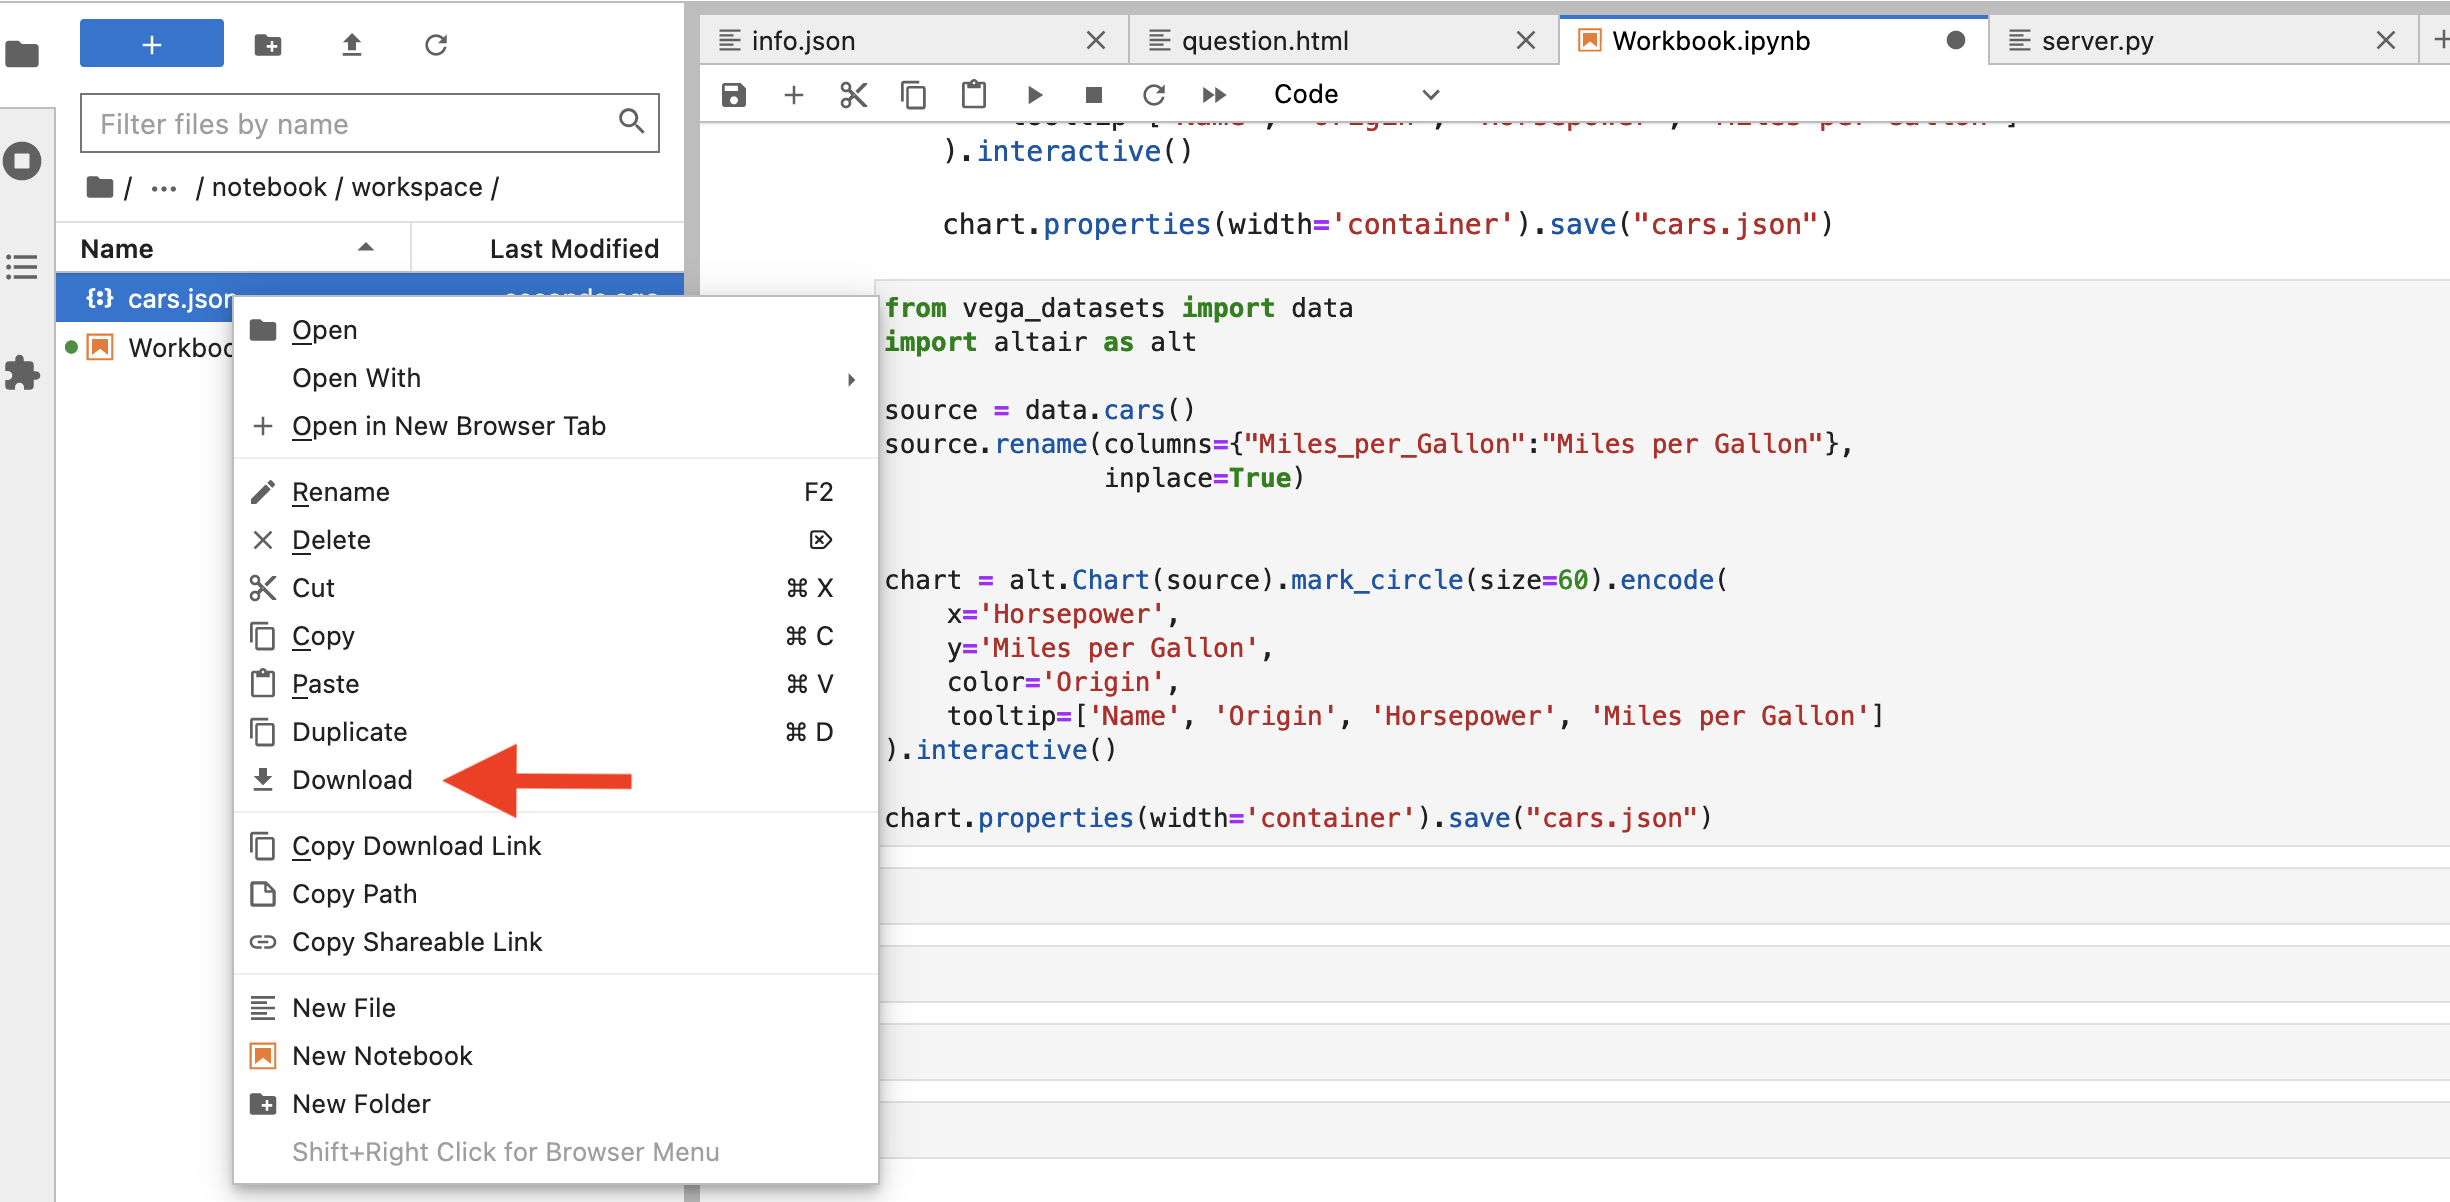

In [1]:
import pandas as pd
import altair as alt
import numpy as np

url = 'https://raw.githubusercontent.com/UIUC-iSchool-DataViz/is445_data/main/ufo-scrubbed-geocoded-time-standardized-00.csv'
df = pd.read_csv(url, header=None)

df.columns = ['datetime', 'city', 'state', 'country', 'shape', 
                  'duration_seconds', 'duration_text', 'comments', 
                  'date_posted', 'latitude', 'longitude']

In [2]:
# print(df_ufo.shape)
# print(df_ufo.head())
# print(df_ufo.info())

In [3]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%m/%d/%Y %H:%M', errors='coerce')
df['year'] = df['datetime'].dt.year

df_us = df[df['country'] == 'us'].copy()
df_us = df_us.dropna(subset=['latitude', 'longitude', 'shape', 'year'])

df_us = df_us[(df_us['latitude'] >= 20) & (df_us['latitude'] <= 72) & 
              (df_us['longitude'] >= -180) & (df_us['longitude'] <= -65)]

df_us = df_us[df_us['year'] >= 1950]

top_shapes = df_us['shape'].value_counts().head(10).index.tolist()
df_us_top_shapes = df_us[df_us['shape'].isin(top_shapes)]

In [4]:
print(f"Cleaned data: {len(df_us)} US sightings")
print(f"Date range: {df_us['year'].min()} - {df_us['year'].max()}")
print(f"Top shapes: {top_shapes}")

Cleaned data: 63410 US sightings
Date range: 1950 - 2014
Top shapes: ['light', 'triangle', 'circle', 'fireball', 'unknown', 'other', 'sphere', 'disk', 'oval', 'formation']


In [5]:
# PLOT 1

df_sample = df_us.sample(n=5000, random_state=42)

plot1 = alt.Chart(df_sample).mark_circle(opacity=0.3,size=10)\
           .encode(longitude='longitude:Q',latitude='latitude:Q',color=alt.Color('shape:N', scale=alt.Scale(scheme='category20'),
                   legend=alt.Legend(title='UFO Shape')),tooltip=['city:N', 'state:N', 'shape:N', 'year:Q', 'duration_text:N'])\
           .properties(width=800, height=500, title='UFO Sightings Across the United States (Sample of 5,000)')\
           .project(type='albersUsa')

plot1

alt.Chart(...)

In [6]:
# PLOT 2

df_time = df_us_top_shapes.groupby(['year', 'shape']).size().reset_index(name='count')

shape_selection = alt.selection_point(fields=['shape'],bind=alt.binding_select(options=[None] + top_shapes,labels=['All Shapes'] + top_shapes,
                                      name='Select UFO Shape:'),value='light')

plot2 = alt.Chart(df_time).mark_line(point=True,strokeWidth=3.5)\
           .encode(x=alt.X('year:Q', title='Year', scale=alt.Scale(domain=[1950, 2014])), y=alt.Y('count:Q', title='No. of Sightings'),
                   color=alt.condition(shape_selection, alt.Color('shape:N', scale=alt.Scale(scheme='tableau20'),legend=alt.Legend(title='Shapes of UFO')),
                            alt.value('lightgray')),opacity=alt.condition(shape_selection, alt.value(1), alt.value(0.2)),tooltip=['year:Q', 'shape:N', 'count:Q'])\
           .add_params(shape_selection)\
           .properties(width=1000, height=600, title='UFO Sightings (1950-2014)')

plot2

alt.Chart(...)

In [7]:
plot1.save('df_ufo_map.json')
plot2.save('df_ufo_timeseries.json')
#saved the plots